In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('customer_churn_.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# DATA CLEANING

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# EDA

In [8]:
df.isna().values.any() # check for missing or null values 

np.False_

In [9]:
df.duplicated().sum() # check for duplicated values

np.int64(0)

In [10]:
# fixing datatypes
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique()[:5])

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges ['29.85' '1889.5' '108.15' '1840.75' '151.65']
Churn ['No' 'Yes']


In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
df['TotalCharges'].dtype # successfully converted to numeric value

dtype('float64')

In [13]:
df['TotalCharges'].isna().sum().sum()

np.int64(11)

In [14]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [15]:
df['TotalCharges'].isna().sum().sum() # removed all null values

np.int64(0)

***Dropping a unnecessary feature from the dataset***

In [16]:
df.drop(['customerID'],axis=1,inplace=True)

***Finding Outliers Using IQR Method***

outliers detected : 1142


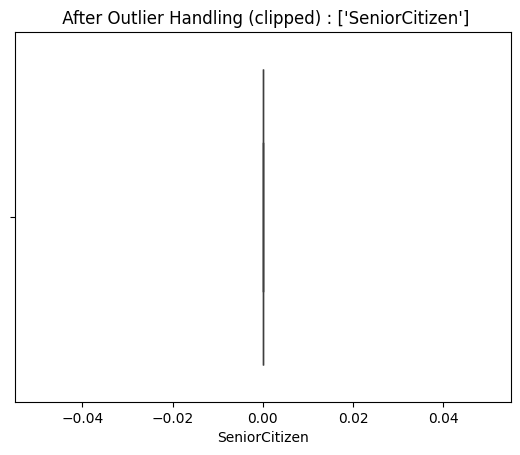

outliers detected : 0


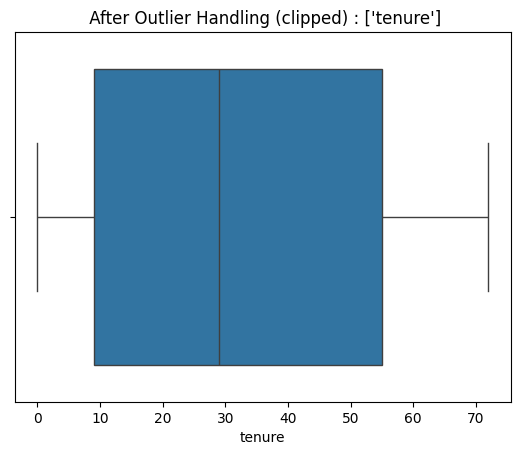

outliers detected : 0


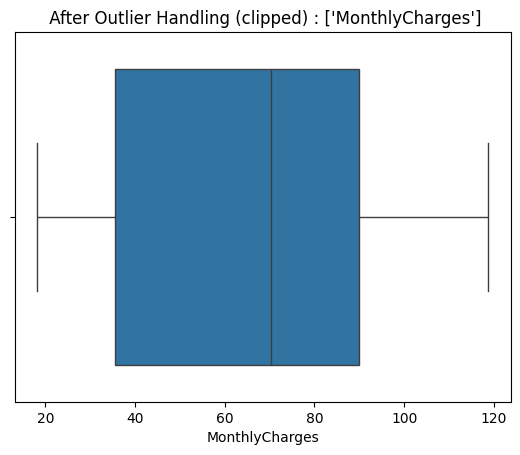

outliers detected : 0


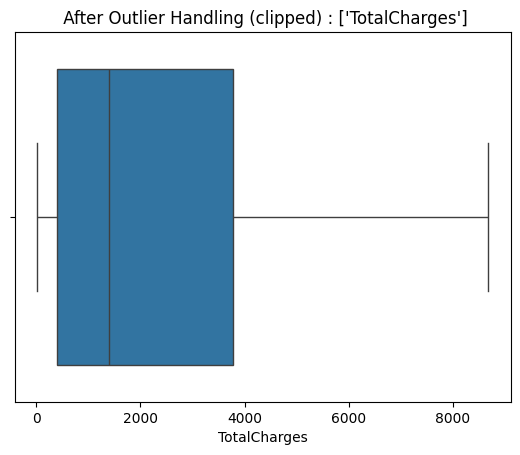

In [17]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5 *IQR
    Upper = Q3 + 1.5 *IQR

    #Outlier count
    outliers = df[(df[col] < lower) | (df[col] > Upper)]
    print(f"outliers detected : {len(outliers)}")

    #Clipping (caping)
    df[col]=df[col].clip(lower,Upper)

    #Plot the outliers
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f" After Outlier Handling (clipped) : {[col]}")
    plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


***Label Encoding***

In [56]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtypes=="object":
        df[col]=le.fit_transform(df[col])

***Separate X and y***

In [57]:
X = df[['gender','Partner','Dependents','tenure','MonthlyCharges','TotalCharges']]
Y = df[['Churn']]

In [58]:
for col in X:
    if df[col].dtype == 'object':
        # Assign the conversion back to the specific column
        df[col] = df[col].astype(int)


In [59]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          7043 non-null   int64  
 1   Partner         7043 non-null   int64  
 2   Dependents      7043 non-null   int64  
 3   tenure          7043 non-null   int64  
 4   MonthlyCharges  7043 non-null   float64
 5   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 330.3 KB


In [60]:
Y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


***Train,Test,Split***

In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

***SCALING(Standardisation or normalisation)***

In [62]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

***PCA (Principal Component Analysis)***

In [63]:
from sklearn.decomposition import PCA
pca=PCA(n_components=6)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

***Train Model(Logistic Regression)***

In [64]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_pca,y_train)

C:\Users\ARYAN SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
y_pred = model.predict(x_test_pca)

In [66]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 79.55997161107167

Confusion Matrix:
[[943  93]
 [195 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



***Train Model(Random Forest)***

In [72]:
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier()

model1.fit(x_train_pca,y_train)

C:\Users\ARYAN SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
y_pred=model1.predict(x_test_pca)
# accuracy score
print("accuracy score :", accuracy_score(y_pred,y_test)*100)


accuracy score : 76.93399574166075


🔹 Accuracy: 0.7622427253371186
🔹 Precision: 0.5678571428571428
🔹 Recall: 0.4262734584450402
🔹 F1 Score: 0.4869831546707504


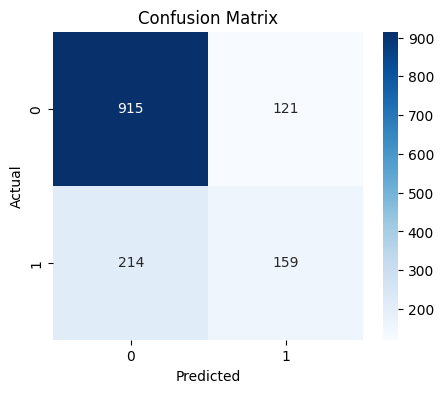


🔹 Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.88      0.85      1036
           1       0.57      0.43      0.49       373

    accuracy                           0.76      1409
   macro avg       0.69      0.65      0.67      1409
weighted avg       0.75      0.76      0.75      1409



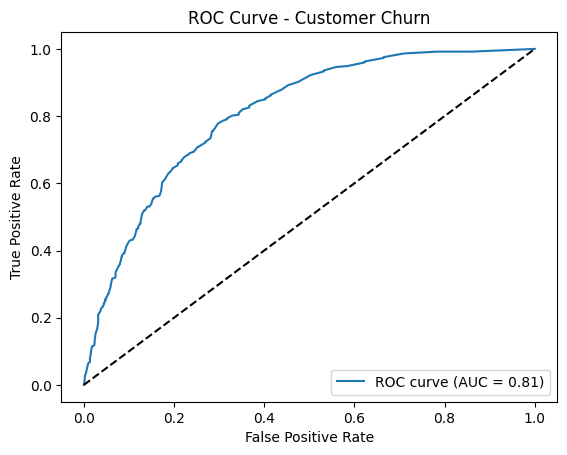

🔹 ROC-AUC Score: 0.8082488846563913

🔹 Feature Importance:

tenure            0.237111
Partner           0.170585
gender            0.165892
TotalCharges      0.150938
Dependents        0.140999
MonthlyCharges    0.134474
dtype: float64


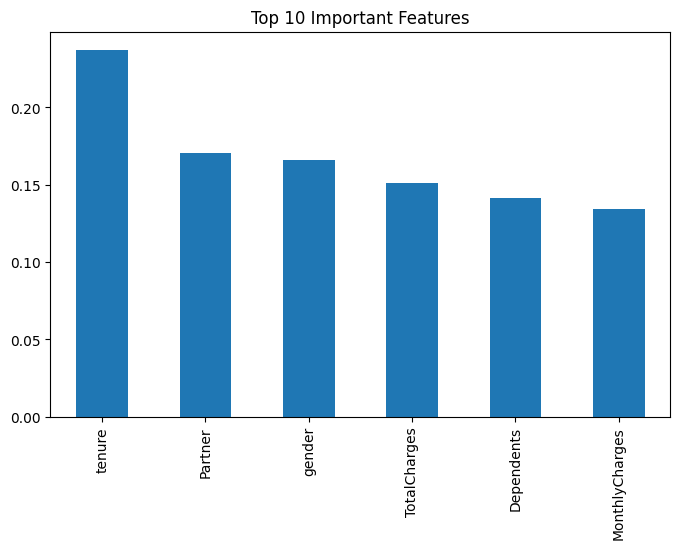

In [74]:

#  Import Required Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)



#  Predictions


# Predict class labels (0 or 1)
y_pred = model.predict(x_test_pca)

# Predict probabilities (needed for ROC curve)
y_prob = model1.predict_proba(x_test_pca)[:, 1]



#  Basic Evaluation Metrics


print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Precision:", precision_score(y_test, y_pred))
print("🔹 Recall:", recall_score(y_test, y_pred))
print("🔹 F1 Score:", f1_score(y_test, y_pred))



# Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 👉 Interpretation:
# TN → correctly predicted non-churn
# TP → correctly predicted churn
# FP → predicted churn but actually not
# FN → predicted not churn but actually churn



#  Classification Report


print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred))



#  ROC Curve & AUC Score


# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn")
plt.legend(loc="lower right")

plt.show()

print("🔹 ROC-AUC Score:", roc_auc)



# ⭐ Feature Importance (if using Random Forest)


try:
    
    
    feature_importance = pd.Series(model.feature_importances_, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=False)
    
    print("\n🔹 Feature Importance:\n")
    print(feature_importance)
    
    # Plot feature importance
    plt.figure(figsize=(8,5))
    feature_importance.head(10).plot(kind='bar')
    plt.title("Top 10 Important Features")
    plt.show()

except:
    print("\n⚠️ Feature importance not available for this model")

In [75]:
classifier=model
# CREATE A PICKLE FILE USING SERIALIZATION

import pickle

with open("classifier.pickle", "wb") as f:
    pickle.dump(classifier, f)